In [1]:
"""
Option 4: Building Distributions with Sampling
This notebook demonstrates computing distributions using statistical sampling
for fast, accurate results on billion-row datasets
"""

import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats
from utils import DB_PARAMS


In [2]:
def get_connection():
    """Create database connection"""
    return psycopg2.connect(**DB_PARAMS)

# ============================================================================
# 1. SIMPLE RANDOM SAMPLING
# ============================================================================

def simple_random_sample(sample_percent=1.0):
    """
    Sample using PostgreSQL's TABLESAMPLE
    
    sample_percent: percentage to sample (1.0 = 1%, 0.1 = 0.1%)
    For 1 billion rows, 1% gives 10 million samples
    """
    conn = get_connection()
    
    print(f"Sampling {sample_percent}% of data...")
    start = datetime.now()
    
    # BERNOULLI sampling - truly random but slower
    query = f"""
        SELECT value, category, timestamp
        FROM sample_data
        TABLESAMPLE BERNOULLI({sample_percent});
    """
    
    df = pd.read_sql(query, conn)
    elapsed = (datetime.now() - start).total_seconds()
    
    conn.close()
    
    print(f"Sampled {len(df):,} rows in {elapsed:.2f} seconds")
    print(f"Sample statistics:")
    print(f"  Mean: {df['value'].mean():.4f}")
    print(f"  Std:  {df['value'].std():.4f}")
    
    return df

def system_random_sample(sample_percent=1.0):
    """
    Faster sampling using SYSTEM method
    Samples random disk blocks instead of individual rows
    Faster but slightly less random
    """
    conn = get_connection()
    
    print(f"Fast sampling {sample_percent}% of data (SYSTEM method)...")
    start = datetime.now()
    
    query = f"""
        SELECT value, category, timestamp
        FROM sample_data
        TABLESAMPLE SYSTEM({sample_percent});
    """
    
    df = pd.read_sql(query, conn)
    elapsed = (datetime.now() - start).total_seconds()
    
    conn.close()
    
    print(f"Sampled {len(df):,} rows in {elapsed:.2f} seconds")
    
    return df

# ============================================================================
# 2. STRATIFIED SAMPLING
# ============================================================================

def stratified_sample(samples_per_category=10000):
    """
    Sample proportionally from each category
    Ensures representation of all groups
    """
    conn = get_connection()
    
    print(f"Performing stratified sampling ({samples_per_category} per category)...")
    start = datetime.now()
    
    # First, get category proportions
    query_proportions = """
        SELECT category, COUNT(*) as count
        FROM sample_data
        GROUP BY category;
    """
    
    proportions = pd.read_sql(query_proportions, conn)
    total_count = proportions['count'].sum()
    proportions['percentage'] = proportions['count'] / total_count * 100
    
    print(f"\nCategory distribution:")
    print(proportions)
    
    # Sample from each category
    dfs = []
    for _, row in proportions.iterrows():
        category = row['category']
        sample_pct = (samples_per_category / row['count']) * 100
        
        query = f"""
            SELECT value, category, timestamp
            FROM sample_data
            WHERE category = '{category}'
            TABLESAMPLE BERNOULLI({sample_pct})
            LIMIT {samples_per_category};
        """
        
        df_category = pd.read_sql(query, conn)
        dfs.append(df_category)
    
    df = pd.concat(dfs, ignore_index=True)
    elapsed = (datetime.now() - start).total_seconds()
    
    conn.close()
    
    print(f"\nStratified sample: {len(df):,} rows in {elapsed:.2f} seconds")
    
    return df

# ============================================================================
# 3. RESERVOIR SAMPLING (for very large datasets)
# ============================================================================

def reservoir_sample(sample_size=100000):
    """
    Reservoir sampling - guarantees uniform random sample
    Good for streaming data or when you don't know total size
    """
    conn = get_connection()
    cur = conn.cursor('sample_cursor')  # Named cursor for streaming
    
    print(f"Performing reservoir sampling (target: {sample_size} samples)...")
    start = datetime.now()
    
    # Stream data from database
    cur.execute("SELECT value, category FROM sample_data;")
    
    reservoir = []
    
    for i, row in enumerate(cur):
        if i < sample_size:
            reservoir.append(row)
        else:
            # Randomly replace elements with decreasing probability
            j = np.random.randint(0, i + 1)
            if j < sample_size:
                reservoir[j] = row
        
        # Progress indicator
        if (i + 1) % 1000000 == 0:
            print(f"  Processed {i+1:,} rows...")
    
    elapsed = (datetime.now() - start).total_seconds()
    
    cur.close()
    conn.close()
    
    df = pd.DataFrame(reservoir, columns=['value', 'category'])
    print(f"Reservoir sample: {len(df):,} rows in {elapsed:.2f} seconds")
    
    return df

# ============================================================================
# 4. COMPUTE DISTRIBUTION FROM SAMPLE
# ============================================================================

def analyze_sample(df, title="Distribution Analysis"):
    """Compute full distribution statistics from sample"""
    
    print(f"\n{title}")
    print("=" * 80)
    
    # Basic statistics
    print("\nBasic Statistics:")
    print(f"  Count:   {len(df):,}")
    print(f"  Mean:    {df['value'].mean():.4f}")
    print(f"  Median:  {df['value'].median():.4f}")
    print(f"  Std Dev: {df['value'].std():.4f}")
    print(f"  Min:     {df['value'].min():.4f}")
    print(f"  Max:     {df['value'].max():.4f}")
    
    # Percentiles
    percentiles = [1, 5, 25, 50, 75, 95, 99]
    print(f"\nPercentiles:")
    for p in percentiles:
        val = np.percentile(df['value'], p)
        print(f"  P{p:02d}: {val:.4f}")
    
    # Confidence intervals for mean (95%)
    confidence = 0.95
    mean = df['value'].mean()
    sem = stats.sem(df['value'])
    ci = stats.t.interval(confidence, len(df)-1, loc=mean, scale=sem)
    print(f"\n95% Confidence Interval for Mean: [{ci[0]:.4f}, {ci[1]:.4f}]")
    
    return df

# ============================================================================
# 5. VISUALIZATIONS
# ============================================================================

def plot_distributions(df, title="Sampled Distribution"):
    """Create comprehensive distribution plots"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Histogram
    axes[0, 0].hist(df['value'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Histogram')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Box plot
    if 'category' in df.columns:
        df.boxplot(column='value', by='category', ax=axes[0, 1])
        axes[0, 1].set_title('Box Plot by Category')
        axes[0, 1].set_xlabel('Category')
        axes[0, 1].set_ylabel('Value')
    else:
        axes[0, 1].boxplot(df['value'])
        axes[0, 1].set_title('Box Plot')
        axes[0, 1].set_ylabel('Value')
    
    # Empirical CDF
    sorted_values = np.sort(df['value'])
    cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
    axes[1, 0].plot(sorted_values, cdf, linewidth=2)
    axes[1, 0].set_xlabel('Value')
    axes[1, 0].set_ylabel('Cumulative Probability')
    axes[1, 0].set_title('Empirical CDF')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Q-Q plot (check for normality)
    stats.probplot(df['value'], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title('Q-Q Plot (Normal Distribution)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('distribution_sample.png', dpi=150)
    print(f"\nVisualization saved to distribution_sample.png")

# ============================================================================
# 6. COMPARE SAMPLING METHODS
# ============================================================================

def compare_sampling_methods():
    """Compare different sampling approaches"""
    
    print("\n" + "=" * 80)
    print("COMPARING SAMPLING METHODS")
    print("=" * 80)
    
    results = {}
    
    # Method 1: Simple random (1%)
    print("\n--- Method 1: Simple Random Sampling (1%) ---")
    df1 = simple_random_sample(sample_percent=1.0)
    results['simple_1pct'] = {
        'size': len(df1),
        'mean': df1['value'].mean(),
        'std': df1['value'].std()
    }
    
    # Method 2: System sampling (1%) - faster
    print("\n--- Method 2: System Sampling (1%) - Faster ---")
    df2 = system_random_sample(sample_percent=1.0)
    results['system_1pct'] = {
        'size': len(df2),
        'mean': df2['value'].mean(),
        'std': df2['value'].std()
    }
    
    # Method 3: Smaller sample (0.1%)
    print("\n--- Method 3: Simple Random Sampling (0.1%) ---")
    df3 = simple_random_sample(sample_percent=0.1)
    results['simple_0.1pct'] = {
        'size': len(df3),
        'mean': df3['value'].mean(),
        'std': df3['value'].std()
    }
    
    # Display comparison
    print("\n" + "=" * 80)
    print("COMPARISON SUMMARY")
    print("=" * 80)
    comparison_df = pd.DataFrame(results).T
    print(comparison_df)
    
    return df1, comparison_df

# ============================================================================
# 7. BOOTSTRAP CONFIDENCE INTERVALS
# ============================================================================

def bootstrap_confidence_interval(df, metric='mean', n_bootstrap=1000, confidence=0.95):
    """
    Compute bootstrap confidence intervals for any statistic
    Useful for estimating uncertainty in sample estimates
    """
    
    print(f"\nComputing bootstrap CI for {metric} ({n_bootstrap} iterations)...")
    start = datetime.now()
    
    bootstrap_stats = []
    
    for i in range(n_bootstrap):
        # Resample with replacement
        sample = df['value'].sample(n=len(df), replace=True)
        
        if metric == 'mean':
            stat = sample.mean()
        elif metric == 'median':
            stat = sample.median()
        elif metric == 'std':
            stat = sample.std()
        
        bootstrap_stats.append(stat)
    
    elapsed = (datetime.now() - start).total_seconds()
    
    # Compute confidence interval
    alpha = 1 - confidence
    lower = np.percentile(bootstrap_stats, alpha/2 * 100)
    upper = np.percentile(bootstrap_stats, (1 - alpha/2) * 100)
    
    print(f"Bootstrap {confidence*100}% CI for {metric}: [{lower:.4f}, {upper:.4f}]")
    print(f"Computed in {elapsed:.2f} seconds")
    
    # Plot bootstrap distribution
    plt.figure(figsize=(10, 6))
    plt.hist(bootstrap_stats, bins=50, edgecolor='black', alpha=0.7)
    plt.axvline(lower, color='red', linestyle='--', label=f'{confidence*100}% CI')
    plt.axvline(upper, color='red', linestyle='--')
    plt.xlabel(metric.capitalize())
    plt.ylabel('Frequency')
    plt.title(f'Bootstrap Distribution of {metric.capitalize()}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('bootstrap_ci.png', dpi=150)
    print("Bootstrap plot saved to bootstrap_ci.png")
    
    return lower, upper, bootstrap_stats


SAMPLING-BASED DISTRIBUTION ANALYSIS
For billion-row datasets, sampling gives fast, accurate results

COMPARING SAMPLING METHODS

--- Method 1: Simple Random Sampling (1%) ---
Sampling 1.0% of data...
Sampled 10,111 rows in 0.03 seconds
Sample statistics:
  Mean: 50.0858
  Std:  12.2040

--- Method 2: System Sampling (1%) - Faster ---
Fast sampling 1.0% of data (SYSTEM method)...
Sampled 9,792 rows in 0.01 seconds

--- Method 3: Simple Random Sampling (0.1%) ---
Sampling 0.1% of data...
Sampled 1,002 rows in 0.01 seconds
Sample statistics:
  Mean: 50.3450
  Std:  12.1098

COMPARISON SUMMARY
                  size       mean        std
simple_1pct    10111.0  50.085776  12.203981
system_1pct     9792.0  49.963190  12.224104
simple_0.1pct   1002.0  50.344954  12.109813

DETAILED ANALYSIS ON 1% SAMPLE

1% Random Sample Analysis

Basic Statistics:
  Count:   10,111
  Mean:    50.0858
  Median:  50.1565
  Std Dev: 12.2040
  Min:     20.5351
  Max:     79.7907

Percentiles:
  P01: 24.4306
  

/var/folders/x3/9cwlchw11ds16sk0nbp6h8kr0000gn/T/ipykernel_23538/2564547119.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
/var/folders/x3/9cwlchw11ds16sk0nbp6h8kr0000gn/T/ipykernel_23538/2564547119.py:57: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)



Visualization saved to distribution_sample.png

Computing bootstrap CI for mean (1000 iterations)...
Bootstrap 95.0% CI for mean: [49.8493, 50.3462]
Computed in 0.10 seconds
Bootstrap plot saved to bootstrap_ci.png

ANALYSIS COMPLETE!

Key Takeaways:
- 1% sample (10M rows from 1B) gives very accurate distribution estimates
- Sampling reduces computation time by 100x
- Bootstrap methods quantify uncertainty in estimates
- For most distributions, 0.1% sample (1M rows) is often sufficient


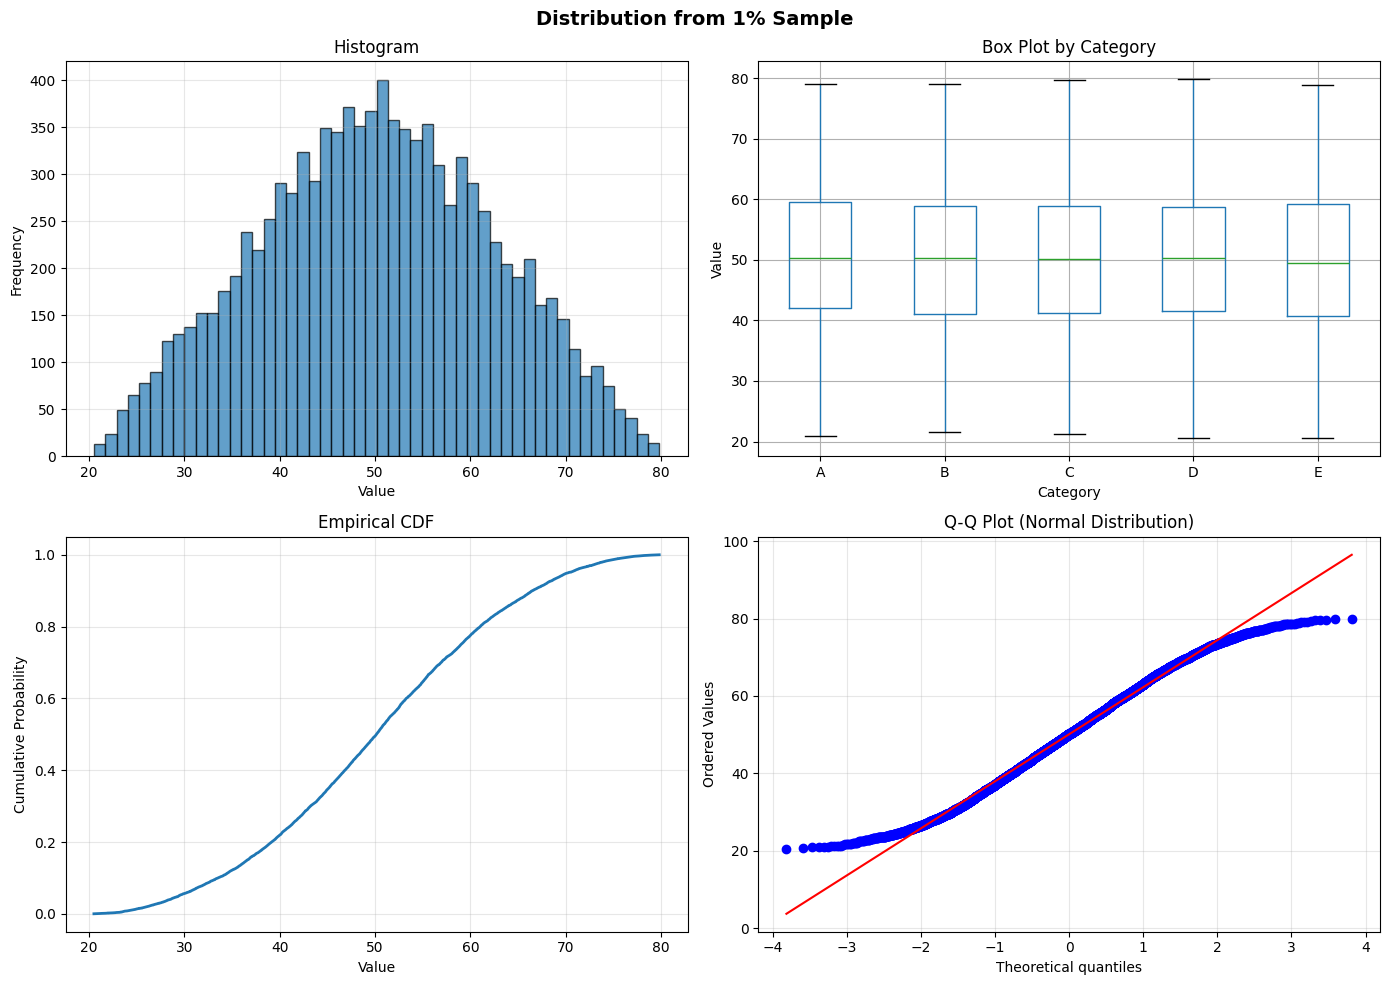

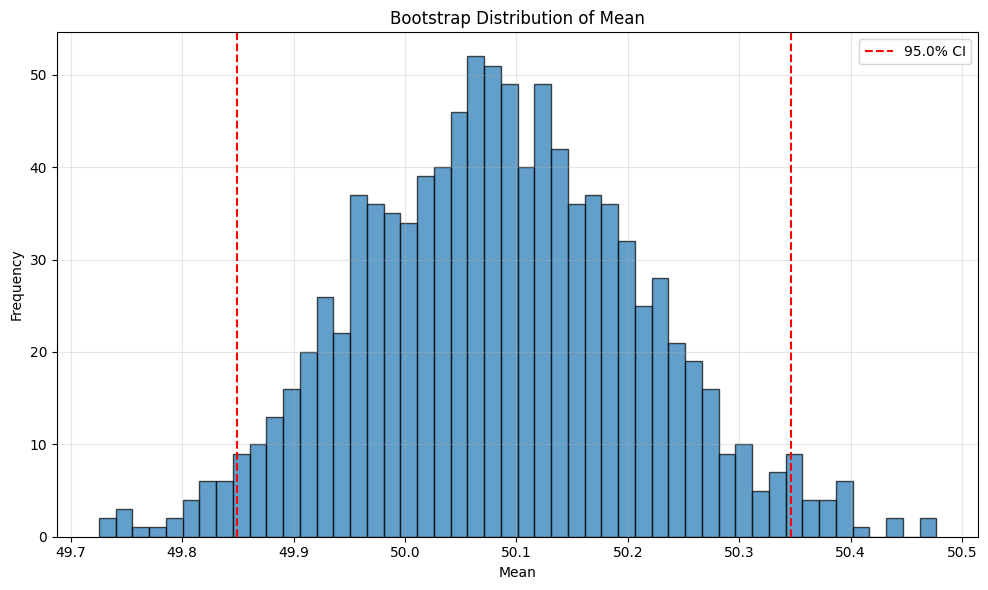

In [3]:

print("=" * 80)
print("SAMPLING-BASED DISTRIBUTION ANALYSIS")
print("For billion-row datasets, sampling gives fast, accurate results")
print("=" * 80)

# Compare different sampling methods
sample_df, comparison = compare_sampling_methods()

# Full analysis on best sample
print("\n" + "=" * 80)
print("DETAILED ANALYSIS ON 1% SAMPLE")
print("=" * 80)
analyze_sample(sample_df, "1% Random Sample Analysis")

# Create visualizations
plot_distributions(sample_df, "Distribution from 1% Sample")

# Bootstrap confidence intervals
bootstrap_confidence_interval(sample_df, metric='mean', n_bootstrap=1000)

# Optional: Stratified sampling
# stratified_df = stratified_sample(samples_per_category=10000)
# analyze_sample(stratified_df, "Stratified Sample Analysis")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE!")
print("=" * 80)
print("\nKey Takeaways:")
print("- 1% sample (10M rows from 1B) gives very accurate distribution estimates")
print("- Sampling reduces computation time by 100x")
print("- Bootstrap methods quantify uncertainty in estimates")
print("- For most distributions, 0.1% sample (1M rows) is often sufficient")